In [1]:
import os, cv2, json, time, random, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import timm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

warnings.filterwarnings("ignore")

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)

if torch.cuda.is_available():
    device = torch.device("cuda")
    print("GPU:", torch.cuda.get_device_name(0))
    torch.backends.cudnn.benchmark = True
else:
    device = torch.device("cpu")
    print("GPU not detected. Install CUDA-enabled PyTorch.")

print("Using:", device)

c:\Users\l1f22bscs0102.UCP\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch: 2.11.0+cpu
CUDA available: False
CUDA version: None
GPU not detected. Install CUDA-enabled PyTorch.
Using: cpu


In [4]:
DATASET_ROOT = r"C:\Users\l1f22bscs0102.UCP\Documents\1.Datasets\Manipulation video dataset\Videosham dataset"

PROCESSED_FOLDERS = [
    os.path.join(DATASET_ROOT, "Processed 1"),
    os.path.join(DATASET_ROOT, "Processed 2"),
]

UNEDITED_FOLDERS = [
    os.path.join(DATASET_ROOT, "Unedited 1"),
    os.path.join(DATASET_ROOT, "Unedited 2"),
]

VIDEO_EXTS = (".mp4", ".avi", ".mov", ".mkv", ".webm")

def collect_videos(folder_list, label):
    data = []
    for folder in folder_list:
        if not os.path.exists(folder):
            print("Folder not found:", folder)
            continue
        for root, _, files in os.walk(folder):
            for file in files:
                if file.lower().endswith(VIDEO_EXTS):
                    data.append({
                        "video_path": os.path.join(root, file),
                        "label": label
                    })
    return data

processed_data = collect_videos(PROCESSED_FOLDERS, 1)
unedited_data = collect_videos(UNEDITED_FOLDERS, 0)

df = pd.DataFrame(processed_data + unedited_data)

print("Total videos:", len(df))
print(df["label"].value_counts())
display(df.head())

Total videos: 1229
label
0    704
1    525
Name: count, dtype: int64


,video_path,label
0,C:\Users\l1f22bscs0102.UCP\Documents\1.Dataset...,1
1,C:\Users\l1f22bscs0102.UCP\Documents\1.Dataset...,1
2,C:\Users\l1f22bscs0102.UCP\Documents\1.Dataset...,1
3,C:\Users\l1f22bscs0102.UCP\Documents\1.Dataset...,1
4,C:\Users\l1f22bscs0102.UCP\Documents\1.Dataset...,1


In [5]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df["label"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["label"]
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

Train: 983
Val: 123
Test: 123


In [6]:
IMG_SIZE = 160
NUM_FRAMES = 4
PATCH_SIZE = 16

CACHE_DIR = Path("vm_tensor_cache_160_4f")
CACHE_DIR.mkdir(exist_ok=True)

MEAN4 = torch.tensor([0.485, 0.456, 0.406, 0.5]).view(4, 1, 1)
STD4 = torch.tensor([0.229, 0.224, 0.225, 0.25]).view(4, 1, 1)

def safe_name(path):
    return str(abs(hash(path))) + ".pt"

def sample_video_frames(video_path, num_frames=4, target_size=160):
    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        return []

    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if frame_count <= 0:
        cap.release()
        return []

    indices = np.linspace(0, frame_count - 1, num_frames, dtype=int)
    frames = []

    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
        ok, frame = cap.read()

        if not ok or frame is None:
            continue

        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frame = cv2.resize(frame, (target_size, target_size), interpolation=cv2.INTER_AREA)
        frames.append(frame)

    cap.release()
    return frames

def fractal_map_fast(gray, patch=16):
    h, w = gray.shape
    H = (h // patch) * patch
    W = (w // patch) * patch

    gray = gray[:H, :W]

    blocks = gray.reshape(H // patch, patch, W // patch, patch)
    blocks = blocks.transpose(0, 2, 1, 3)

    thresholds = np.array([64, 96, 128, 160, 192], dtype=np.uint8)
    counts = (blocks[..., None] > thresholds).sum(axis=(2, 3))

    fmap_small = counts.std(axis=2).astype(np.float32)
    fmap = cv2.resize(fmap_small, (W, H), interpolation=cv2.INTER_CUBIC)

    fmap = fmap - fmap.min()
    fmap = fmap / (fmap.max() + 1e-6)

    return fmap

def build_4ch_tensor(rgb_frame, patch=16):
    gray = cv2.cvtColor(rgb_frame, cv2.COLOR_RGB2GRAY)
    fmap = fractal_map_fast(gray, patch)

    if fmap.shape[:2] != rgb_frame.shape[:2]:
        fmap = cv2.resize(fmap, (rgb_frame.shape[1], rgb_frame.shape[0]))

    rgb = rgb_frame.astype(np.float32) / 255.0
    frame4 = np.dstack([rgb, fmap.astype(np.float32)])

    tensor = torch.from_numpy(frame4).permute(2, 0, 1).float()
    tensor = (tensor - MEAN4) / STD4

    return tensor

def video_to_clip_tensor(video_path, num_frames=4, img_size=160, patch=16):
    frames = sample_video_frames(video_path, num_frames, img_size)

    if len(frames) == 0:
        return torch.zeros(num_frames, 4, img_size, img_size)

    tensors = [build_4ch_tensor(frame, patch) for frame in frames]

    while len(tensors) < num_frames:
        tensors.append(tensors[-1].clone())

    return torch.stack(tensors[:num_frames], dim=0)

In [7]:
def build_cache(dataframe, name="train"):
    print(f"Building cache for {name}: {len(dataframe)} videos")

    bad = 0

    for _, row in tqdm(dataframe.iterrows(), total=len(dataframe)):
        path = row["video_path"]
        out_path = CACHE_DIR / safe_name(path)

        if out_path.exists():
            continue

        try:
            clip = video_to_clip_tensor(path, NUM_FRAMES, IMG_SIZE, PATCH_SIZE)

            torch.save({
                "clip": clip,
                "label": int(row["label"]),
                "video_path": path
            }, out_path)

        except Exception as e:
            bad += 1
            print("Cache error:", path, e)

    print("Bad videos:", bad)

build_cache(train_df, "train")
build_cache(val_df, "val")
build_cache(test_df, "test")

print("Cache ready:", CACHE_DIR.resolve())

Building cache for train: 983 videos


100%|██████████| 983/983 [03:06<00:00,  5.28it/s]


Bad videos: 0
Building cache for val: 123 videos


100%|██████████| 123/123 [00:23<00:00,  5.32it/s]


Bad videos: 0
Building cache for test: 123 videos


100%|██████████| 123/123 [00:27<00:00,  4.52it/s]

Bad videos: 0
Cache ready: C:\Users\l1f22bscs0102.UCP\Documents\4.Visual manipulation code\vm_tensor_cache_160_4f


In [8]:
class CachedVideoDataset(Dataset):
    def __init__(self, dataframe):
        self.df = dataframe.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        item = torch.load(CACHE_DIR / safe_name(row["video_path"]), map_location="cpu")
        return item["clip"], torch.tensor(item["label"], dtype=torch.long)

BATCH_SIZE = 4 if torch.cuda.is_available() else 1
NUM_WORKERS = 0

train_loader = DataLoader(
    CachedVideoDataset(train_df),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    CachedVideoDataset(val_df),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    CachedVideoDataset(test_df),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

clips, labels = next(iter(train_loader))
print("Batch shape:", clips.shape)
print("Labels:", labels)

Batch shape: torch.Size([1, 4, 4, 160, 160])
Labels: tensor([0])


In [9]:
class VideoManipulationModel(nn.Module):
    def __init__(self, backbone_name="efficientnet_b0", num_classes=2):
        super().__init__()

        self.backbone = timm.create_model(
            backbone_name,
            pretrained=True,
            num_classes=0
        )

        old_conv = self.backbone.conv_stem

        new_conv = nn.Conv2d(
            in_channels=4,
            out_channels=old_conv.out_channels,
            kernel_size=old_conv.kernel_size,
            stride=old_conv.stride,
            padding=old_conv.padding,
            bias=(old_conv.bias is not None)
        )

        with torch.no_grad():
            new_conv.weight[:, :3] = old_conv.weight
            new_conv.weight[:, 3:4] = old_conv.weight.mean(dim=1, keepdim=True)

        self.backbone.conv_stem = new_conv

        feat_dim = self.backbone.num_features

        self.classifier = nn.Sequential(
            nn.Dropout(0.30),
            nn.Linear(feat_dim, num_classes)
        )

    def forward(self, x):
        B, T, C, H, W = x.shape

        x = x.reshape(B * T, C, H, W)

        features = self.backbone(x)

        features = features.reshape(B, T, -1)
        features = features.mean(dim=1)

        output = self.classifier(features)

        return output

model = VideoManipulationModel().to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=2e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=8
)

scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

print("Parameters:", sum(p.numel() for p in model.parameters()) / 1e6, "M")

Parameters: 4.010398 M


In [10]:
def run_train_epoch(model, loader):
    model.train()

    losses = []
    preds = []
    trues = []

    pbar = tqdm(loader, desc="Training", leave=False)

    for clips, labels in pbar:
        clips = clips.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            logits = model(clips)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        losses.append(loss.item() * clips.size(0))
        preds.extend(torch.argmax(logits, dim=1).detach().cpu().tolist())
        trues.extend(labels.detach().cpu().tolist())

        pbar.set_postfix(loss=loss.item())

    epoch_loss = sum(losses) / len(loader.dataset)
    epoch_acc = accuracy_score(trues, preds)

    return epoch_loss, epoch_acc

@torch.no_grad()
def run_eval_epoch(model, loader, name="Validation"):
    model.eval()

    losses = []
    preds = []
    trues = []
    probs = []

    for clips, labels in tqdm(loader, desc=name, leave=False):
        clips = clips.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            logits = model(clips)
            loss = criterion(logits, labels)

        prob = torch.softmax(logits, dim=1)[:, 1]

        losses.append(loss.item() * clips.size(0))
        preds.extend(torch.argmax(logits, dim=1).cpu().tolist())
        trues.extend(labels.cpu().tolist())
        probs.extend(prob.cpu().tolist())

    epoch_loss = sum(losses) / len(loader.dataset)
    epoch_acc = accuracy_score(trues, preds)

    try:
        epoch_auc = roc_auc_score(trues, probs)
    except:
        epoch_auc = 0.0

    return epoch_loss, epoch_acc, epoch_auc, trues, preds, probs

In [10]:
EPOCHS = 10
SAVE_PATH = "best_visual_manipulation.pth"

best_auc = -1

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "val_auc": []
}

start = time.time()

for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch {epoch}/{EPOCHS}")

    train_loss, train_acc = run_train_epoch(model, train_loader)

    val_loss, val_acc, val_auc, _, _, _ = run_eval_epoch(
        model,
        val_loader,
        "Validation"
    )

    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_auc"].append(val_auc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f} | Val AUC: {val_auc:.4f}")

    if val_auc > best_auc:
        best_auc = val_auc

        torch.save({
            "model_state_dict": model.state_dict(),
            "backbone": "efficientnet_b0",
            "img_size": IMG_SIZE,
            "num_frames": NUM_FRAMES,
            "patch_size": PATCH_SIZE,
            "classes": ["Unedited", "Manipulated"]
        }, SAVE_PATH)

        print("Best model saved:", SAVE_PATH)

print("Training time minutes:", round((time.time() - start) / 60, 2))


Epoch 1/10


Train Loss: 0.6645 | Train Acc: 0.6317
Val Loss:   0.7032 | Val Acc:   0.4309 | Val AUC: 0.4601
Best model saved: best_visual_manipulation.pth

Epoch 2/10


Train Loss: 0.6413 | Train Acc: 0.6857
Val Loss:   0.6851 | Val Acc:   0.5772 | Val AUC: 0.5181
Best model saved: best_visual_manipulation.pth

Epoch 3/10


Train Loss: 0.5996 | Train Acc: 0.7141
Val Loss:   0.6881 | Val Acc:   0.5285 | Val AUC: 0.5482
Best model saved: best_visual_manipulation.pth

Epoch 4/10


Train Loss: 0.5408 | Train Acc: 0.7752
Val Loss:   0.7411 | Val Acc:   0.4878 | Val AUC: 0.4420

Epoch 5/10


...

Train Loss: 0.5120 | Train Acc: 0.7731
Val Loss:   0.7253 | Val Acc:   0.5528 | Val AUC: 0.4151

Epoch 7/10


Train Loss: 0.5259 | Train Acc: 0.7396
Val Loss:   0.7188 | Val Acc:   0.5366 | Val AUC: 0.4722

Epoch 8/10


Train Loss: 0.5431 | Train Acc: 0.7335
Val Loss:   0.7341 | Val Acc:   0.5610 | Val AUC: 0.4981

Epoch 9/10


Train Loss: 0.5672 | Train Acc: 0.7131
Val Loss:   0.7056 | Val Acc:   0.5691 | Val AUC: 0.5396

Epoch 10/10


Train Loss: 0.5966 | Train Acc: 0.6968
Val Loss:   0.7639 | Val Acc:   0.5447 | Val AUC: 0.4574
Training time minutes: 51.66


NameError: name 'history' is not defined

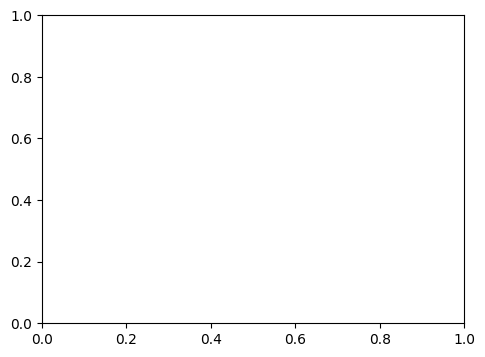

In [11]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.title("Loss Curve")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history["train_acc"], label="Train Acc")
plt.plot(history["val_acc"], label="Val Acc")
plt.plot(history["val_auc"], label="Val AUC")
plt.title("Accuracy / AUC Curve")
plt.legend()

plt.show()

In [14]:
checkpoint = torch.load(r"C:\Users\l1f22bscs0102.UCP\Documents\5.Visual manipulation model\best_visual_manipulation.pth", map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])

test_loss, test_acc, test_auc, y_true, y_pred, y_prob = run_eval_epoch(
    model,
    test_loader,
    "Test"
)

print("Test Loss:", round(test_loss, 4))
print("Test Acc:", round(test_acc, 4))
print("Test AUC:", round(test_auc, 4))

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

print("Classification Report:")
print(classification_report(
    y_true,
    y_pred,
    target_names=["Unedited", "Manipulated"]
))

Test:   0%|          | 0/123 [00:00<?, ?it/s]

Test Loss: 0.6714
Test Acc: 0.5528
Test AUC: 0.5939
Confusion Matrix:
[[44 27]
 [28 24]]
Classification Report:
              precision    recall  f1-score   support

    Unedited       0.61      0.62      0.62        71
 Manipulated       0.47      0.46      0.47        52

    accuracy                           0.55       123
   macro avg       0.54      0.54      0.54       123
weighted avg       0.55      0.55      0.55       123



In [65]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch

MEAN4 = [0.485, 0.456, 0.406, 0.5]
STD4  = [0.229, 0.224, 0.225, 0.25]


def validate_video_duration(video_path, min_seconds=5, max_seconds=10):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return False, "Video open nahi ho rahi"

    fps = cap.get(cv2.CAP_PROP_FPS)
    frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()

    if fps <= 0:
        return False, "FPS read nahi ho raha"

    duration = frames / fps

    if duration < min_seconds:
        return False, f"Video too short: {duration:.2f}s"

    if duration > max_seconds:
        return False, f"Video too long: {duration:.2f}s"

    return True, f"Video OK: {duration:.2f}s"


def sample_video_frames(video_path, num_frames=8, target_size=160):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return []

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total_frames <= 0:
        cap.release()
        return []

    indices = np.linspace(0, total_frames - 1, num_frames, dtype=int)
    frames = []

    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
        ret, frame = cap.read()

        if not ret or frame is None:
            continue

        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frame = cv2.resize(frame, (target_size, target_size))
        frames.append(frame)

    cap.release()
    return frames


def fractal_map_fast(gray, patch=16):
    h, w = gray.shape
    H = (h // patch) * patch
    W = (w // patch) * patch

    gray_crop = gray[:H, :W]

    blocks = gray_crop.reshape(H // patch, patch, W // patch, patch)
    blocks = blocks.transpose(0, 2, 1, 3)

    thresholds = np.array([64, 96, 128, 160, 192], dtype=np.uint8)
    counts = (blocks[..., None] > thresholds).sum(axis=(2, 3))

    fmap_small = counts.std(axis=2).astype(np.float32)
    fmap = cv2.resize(fmap_small, (W, H), interpolation=cv2.INTER_CUBIC)

    fmap = fmap - fmap.min()
    fmap = fmap / (fmap.max() + 1e-6)

    fmap = cv2.resize(fmap, (w, h))
    return np.clip(fmap, 0, 1)


def build_4ch_frame(rgb_frame, patch=16):
    gray = cv2.cvtColor(rgb_frame, cv2.COLOR_RGB2GRAY)
    fmap = fractal_map_fast(gray, patch=patch)

    rgb = rgb_frame.astype(np.float32) / 255.0
    frame4 = np.dstack([rgb, fmap.astype(np.float32)])
    return frame4


def transform_infer(frame4):
    tensor = torch.from_numpy(frame4).permute(2, 0, 1).float()

    for i in range(4):
        tensor[i] = (tensor[i] - MEAN4[i]) / STD4[i]

    return tensor


def prepare_video_clip_from_frames(frames, num_frames=8, patch=16):
    tensor_frames = []

    for frame in frames:
        frame4 = build_4ch_frame(frame, patch=patch)
        tensor_frames.append(transform_infer(frame4))

    while len(tensor_frames) < num_frames:
        tensor_frames.append(tensor_frames[-1].clone())

    clip = torch.stack(tensor_frames[:num_frames], dim=0).unsqueeze(0)
    return clip


def predict_full_video(frames, model, device, num_frames=8, patch=16):
    clip = prepare_video_clip_from_frames(frames, num_frames=num_frames, patch=patch)
    clip = clip.to(device)

    model.eval()
    with torch.no_grad():
        logits = model(clip)
        probs = torch.softmax(logits, dim=1)[0].detach().cpu().numpy()

    return float(probs[0]), float(probs[1])


def normalize_map(x):
    x = x.astype(np.float32)
    x = x - x.min()
    x = x / (x.max() + 1e-6)
    return np.clip(x, 0, 1)


def texture_anomaly_map(rgb_frame, patch=16):
    gray = cv2.cvtColor(rgb_frame, cv2.COLOR_RGB2GRAY)

    fmap = fractal_map_fast(gray, patch=patch)

    edges = cv2.Canny(gray, 80, 160).astype(np.float32) / 255.0

    blur = cv2.GaussianBlur(gray, (9, 9), 0)
    residual = cv2.absdiff(gray, blur).astype(np.float32) / 255.0

    combined = 0.50 * normalize_map(fmap) + 0.25 * normalize_map(edges) + 0.25 * normalize_map(residual)
    return normalize_map(combined)


def temporal_difference_map(frame, all_frames):
    stack = np.stack(all_frames, axis=0).astype(np.float32)
    median_frame = np.median(stack, axis=0).astype(np.uint8)

    diff = cv2.absdiff(frame, median_frame)
    diff_gray = cv2.cvtColor(diff, cv2.COLOR_RGB2GRAY).astype(np.float32) / 255.0

    return normalize_map(diff_gray)


def patch_model_probability_map(
    rgb_frame,
    model,
    device,
    num_frames=8,
    patch_for_fractal=16,
    grid=8
):
    H, W = rgb_frame.shape[:2]
    patch_size = H // grid

    prob_map = np.zeros((H, W), dtype=np.float32)
    count_map = np.zeros((H, W), dtype=np.float32)

    blurred = cv2.GaussianBlur(rgb_frame, (0, 0), sigmaX=7, sigmaY=7)

    model.eval()

    for y in range(0, H - patch_size + 1, patch_size):
        for x in range(0, W - patch_size + 1, patch_size):

            masked = blurred.copy()
            masked[y:y+patch_size, x:x+patch_size] = rgb_frame[y:y+patch_size, x:x+patch_size]

            frames = [masked.copy() for _ in range(num_frames)]
            clip = prepare_video_clip_from_frames(frames, num_frames=num_frames, patch=patch_for_fractal)
            clip = clip.to(device)

            with torch.no_grad():
                logits = model(clip)
                probs = torch.softmax(logits, dim=1)[0].detach().cpu().numpy()

            prob_manipulated = float(probs[1])

            prob_map[y:y+patch_size, x:x+patch_size] += prob_manipulated
            count_map[y:y+patch_size, x:x+patch_size] += 1.0

    prob_map = prob_map / np.maximum(count_map, 1e-6)
    return normalize_map(prob_map), prob_map


def combined_manipulation_map(
    frame,
    all_frames,
    model,
    device,
    num_frames=8,
    patch=16,
    grid=8
):
    model_map_norm, model_map_raw = patch_model_probability_map(
        rgb_frame=frame,
        model=model,
        device=device,
        num_frames=num_frames,
        patch_for_fractal=patch,
        grid=grid
    )

    texture_map = texture_anomaly_map(frame, patch=patch)
    temporal_map = temporal_difference_map(frame, all_frames)

    combined = (
        0.50 * model_map_norm +
        0.30 * texture_map +
        0.20 * temporal_map
    )

    combined = normalize_map(combined)

    return combined, model_map_raw, texture_map, temporal_map


def select_best_suspicious_frame(
    frames,
    model,
    device,
    num_frames=8,
    patch=16,
    grid=8
):
    best_score = -1
    best_data = None

    for idx, frame in enumerate(frames):
        combined, model_raw, texture_map, temporal_map = combined_manipulation_map(
            frame=frame,
            all_frames=frames,
            model=model,
            device=device,
            num_frames=num_frames,
            patch=patch,
            grid=grid
        )

        top_pixels = np.percentile(combined, 90)
        score = float(combined[combined >= top_pixels].mean())

        if score > best_score:
            best_score = score
            best_data = {
                "frame_index": idx,
                "frame": frame,
                "combined_map": combined,
                "model_raw": model_raw,
                "texture_map": texture_map,
                "temporal_map": temporal_map,
                "score": score
            }

    return best_data


def create_overlay(rgb_frame, anomaly_map):
    heat_u8 = np.uint8(anomaly_map * 255)
    heatmap = cv2.applyColorMap(heat_u8, cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    overlay = cv2.addWeighted(rgb_frame, 0.60, heatmap, 0.40, 0)
    return overlay


def predict_video_visual_manipulation(
    video_path,
    model,
    device,
    num_frames=8,
    img_size=160,
    patch=16,
    threshold=0.60,
    grid=8,
    show=True
):
    ok, msg = validate_video_duration(video_path, min_seconds=5, max_seconds=20)
    print(msg)

    if not ok:
        return None

    frames = sample_video_frames(
        video_path=video_path,
        num_frames=num_frames,
        target_size=img_size
    )

    if len(frames) == 0:
        print("Could not read video.")
        return None

    prob_unedited, prob_manipulated = predict_full_video(
        frames=frames,
        model=model,
        device=device,
        num_frames=num_frames,
        patch=patch
    )

    prediction = "Manipulated" if prob_manipulated >= prob_unedited else "Unedited"

    result = {
        "video_path": video_path,
        "prediction": prediction,
        "prob_unedited": prob_unedited,
        "prob_manipulated": prob_manipulated,
        "confidence": max(prob_unedited, prob_manipulated)
    }

    if prediction == "Manipulated":
        best = select_best_suspicious_frame(
            frames=frames,
            model=model,
            device=device,
            num_frames=num_frames,
            patch=patch,
            grid=grid
        )

        frame = best["frame"]
        anomaly_map = best["combined_map"]

        mean_val = float(np.mean(anomaly_map))
        std_val = float(np.std(anomaly_map))

        adaptive_thr = mean_val + 1.2 * std_val
        adaptive_thr = min(max(adaptive_thr, 0.35), 0.80)

        hot_mask = (anomaly_map >= adaptive_thr).astype(np.uint8)

        kernel = np.ones((3, 3), np.uint8)
        hot_mask = cv2.morphologyEx(hot_mask, cv2.MORPH_OPEN, kernel)
        hot_mask = cv2.morphologyEx(hot_mask, cv2.MORPH_CLOSE, kernel)

        suspicious_area = float(hot_mask.mean() * 100)
        overlay = create_overlay(frame, anomaly_map)

        result["best_frame_index"] = int(best["frame_index"])
        result["suspicious_area_percent"] = round(suspicious_area, 2)

        if show:
            plt.figure(figsize=(18, 4))

            plt.subplot(1, 5, 1)
            plt.imshow(frame)
            plt.title(f"Selected Suspicious Frame\nIndex: {best['frame_index']}")
            plt.axis("off")

            plt.subplot(1, 5, 2)
            plt.imshow(overlay)
            plt.title("Manipulation Heatmap Overlay")
            plt.axis("off")

            plt.subplot(1, 5, 3)
            plt.imshow(hot_mask, cmap="gray")
            plt.title(f"Hot Mask\nSuspicious Area: {suspicious_area:.2f}%")
            plt.axis("off")

            plt.subplot(1, 5, 4)
            plt.imshow(anomaly_map, cmap="inferno")
            plt.title("Combined Manipulation Map")
            plt.axis("off")

            plt.subplot(1, 5, 5)
            plt.bar(["Unedited", "Manipulated"], [prob_unedited, prob_manipulated])
            plt.ylim(0, 1)
            plt.title("Global Probability")
            plt.ylabel("Probability")

            plt.tight_layout()
            plt.show()

            plt.figure(figsize=(15, 4))

            plt.subplot(1, 3, 1)
            plt.imshow(best["model_raw"], cmap="inferno")
            plt.title("Model Patch Probability")
            plt.axis("off")

            plt.subplot(1, 3, 2)
            plt.imshow(best["texture_map"], cmap="inferno")
            plt.title("Fractal / Texture Difference")
            plt.axis("off")

            plt.subplot(1, 3, 3)
            plt.imshow(best["temporal_map"], cmap="inferno")
            plt.title("Temporal Frame Difference")
            plt.axis("off")

            plt.tight_layout()
            plt.show()

    else:
        result["best_frame_index"] = None
        result["suspicious_area_percent"] = 0.0

        if show:
            frame = frames[len(frames) // 2]
            black = np.zeros((img_size, img_size), dtype=np.uint8)

            plt.figure(figsize=(14, 4))

            plt.subplot(1, 3, 1)
            plt.imshow(frame)
            plt.title("Input Frame")
            plt.axis("off")

            plt.subplot(1, 3, 2)
            plt.bar(["Unedited", "Manipulated"], [prob_unedited, prob_manipulated])
            plt.ylim(0, 1)
            plt.title("Global Probability")
            plt.ylabel("Probability")

            plt.subplot(1, 3, 3)
            plt.imshow(black, cmap="gray")
            plt.title("No Suspicious Area")
            plt.axis("off")

            plt.tight_layout()
            plt.show()

    print("Prediction:", result["prediction"])
    print("Prob Unedited:", result["prob_unedited"])
    print("Prob Manipulated:", result["prob_manipulated"])
    print("Confidence:", result["confidence"])
    print("Best Frame Index:", result["best_frame_index"])
    print("Suspicious Area %:", result["suspicious_area_percent"])

    return result

Video OK: 10.01s


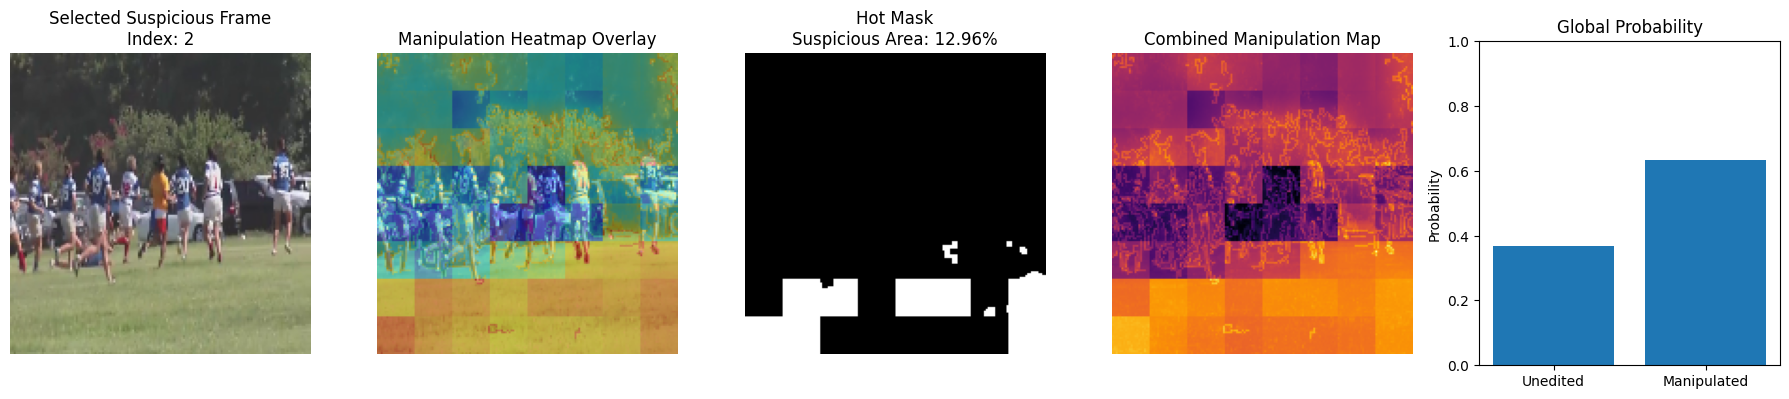

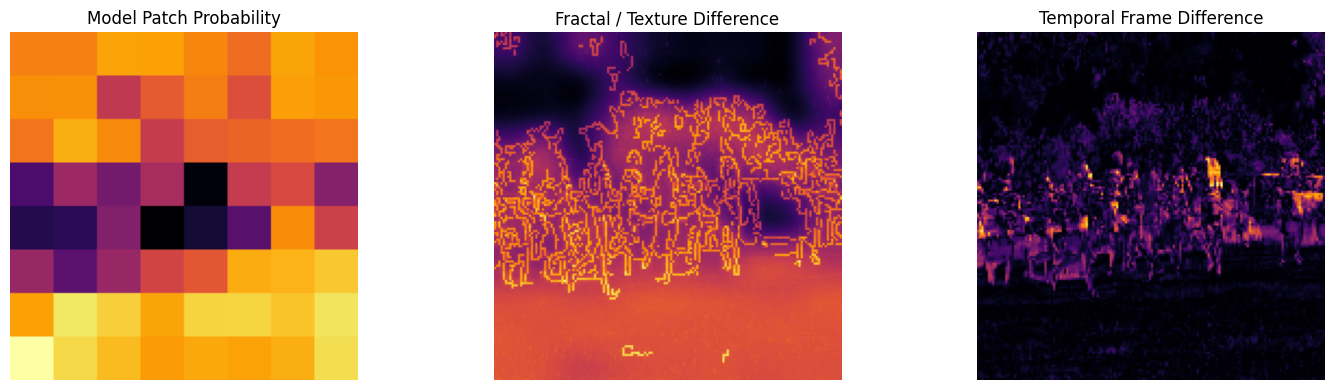

Prediction: Manipulated
Prob Unedited: 0.3673904836177826
Prob Manipulated: 0.6326096057891846
Confidence: 0.6326096057891846
Best Frame Index: 2
Suspicious Area %: 12.96
{'video_path': 'C:\\Users\\l1f22bscs0102.UCP\\Documents\\1.Datasets\\Manipulation video dataset\\Videosham dataset\\Processed 2\\4203_processed.mp4', 'prediction': 'Manipulated', 'prob_unedited': 0.3673904836177826, 'prob_manipulated': 0.6326096057891846, 'confidence': 0.6326096057891846, 'best_frame_index': 2, 'suspicious_area_percent': 12.96}


In [66]:
video_path = r"C:\Users\l1f22bscs0102.UCP\Documents\1.Datasets\Manipulation video dataset\Videosham dataset\Processed 2\4203_processed.mp4"

result = predict_video_visual_manipulation(
    video_path=video_path,
    model=model,
    device=device,
    num_frames=NUM_FRAMES,
    img_size=IMG_SIZE,
    patch=PATCH_SIZE,
    threshold=0.60,
    grid=8,
    show=True
)

print(result)